# Task
Fetch stock data for a user-specified Taiwanese stock ticker for the past 10 years and save it to a CSV file.

## 安裝必要的套件

### Subtask:
安裝用於股票資料抓取的 `yfinance` 套件。


**Reasoning**:
The subtask requires installing the `yfinance` package, so I will use `pip` to install it.



In [152]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## 匯入所需套件

### Subtask:
匯入 `yfinance` 和 `pandas` 套件，以便進行資料抓取與處理。


**Reasoning**:
The subtask requires importing `yfinance` and `pandas` packages. I will create a code block to import these packages, aliasing `pandas` as `pd`.



In [153]:
import yfinance as yf
import pandas as pd
print("yfinance and pandas packages imported successfully.")

yfinance and pandas packages imported successfully.


## 定義抓取股票資料的函數

### Subtask:
建立一個函數，輸入股票代碼，抓取近十年的每日收盤價、最高價、最低價等資訊。


**Reasoning**:
The subtask requires defining a function to fetch stock data for the past 10 years. I will create a Python function `fetch_stock_data` that takes a ticker as input, calculates the start and end dates, uses `yfinance` to download the historical data, and returns a pandas DataFrame.



In [154]:
from datetime import datetime, timedelta

def fetch_stock_data(ticker):
    """
    Fetches historical stock data for a given ticker for the past 10 years.

    Args:
        ticker (str): The stock ticker symbol (e.g., '2330.TW' for TSMC).

    Returns:
        pandas.DataFrame: Historical stock data including Open, High, Low, Close, Volume, etc.
                          Returns an empty DataFrame if data fetching fails.
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=10*365) # Approximate 10 years

    try:
        stock = yf.Ticker(ticker)
        # Fetch daily data for the specified period
        data = stock.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
        if data.empty:
            print(f"No data found for {ticker} in the last 10 years.")
        else:
            print(f"Successfully fetched data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame() # Return an empty DataFrame on error

print("fetch_stock_data function defined.")

fetch_stock_data function defined.


## 讓使用者輸入股票代碼

### Subtask:
提示使用者輸入要查詢的台灣股票代碼。


**Reasoning**:
The subtask requires prompting the user for a Taiwanese stock ticker and reminding them about the '.TW' suffix. I will use the `input()` function to get the ticker from the user and store it in a variable.



In [155]:
# @title
ticker_symbol = input("請輸入要查詢的台灣股票代碼 (例如 '2330.TW'，請務必加上 '.TW' 後綴): ")
print(f"您輸入的股票代碼是: {ticker_symbol}")

您輸入的股票代碼是: 2330.TW


In [156]:
stock_data = fetch_stock_data(ticker_symbol)

if not stock_data.empty:
    filename = f"{ticker_symbol.replace('.TW', '')}_stock_data.csv"
    stock_data.to_csv(filename, index=True) # index=True to save the Date as a column
    print(f"股票資料已成功儲存為 {filename}")
else:
    print(f"無法為 {ticker_symbol} 抓取到股票資料，因此沒有檔案儲存。")

Successfully fetched data for 2330.TW from 2016-04-09 to 2026-04-07.
股票資料已成功儲存為 2330_stock_data.csv


In [157]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 1. Load the data into a DataFrame and remove rows with missing Close values
file_path = filename
stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
original_last_date = pd.to_datetime(stock_df.index.max())
raw_rows = len(stock_df)
stock_df = stock_df.dropna(subset=['Close']).copy()
removed_rows = raw_rows - len(stock_df)
latest_valid_close_date = pd.to_datetime(stock_df.index.max())
print(f"Data loaded from {file_path}. First 5 cleaned rows:\n{stock_df.head()}\n")
if removed_rows > 0:
    print(f"Removed {removed_rows} row(s) with missing Close price to avoid NaN metrics.")
print(f"Original last date in raw file: {original_last_date.date()}")
print(f"Latest valid Close date after cleaning: {latest_valid_close_date.date()}")
print(f"Clean date range: {stock_df.index.min().date()} to {stock_df.index.max().date()}\n")

# 2. Extract Close prices
close_prices = stock_df[['Close']].values
print(f"'Close' prices extracted. Shape: {close_prices.shape}\n")

# 3. Instantiate MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 4. Fit and transform Close prices
scaled_close_prices = scaler.fit_transform(close_prices)
print("Close prices standardized using MinMaxScaler.")
print(f"Scaled Close prices first 5 values: {scaled_close_prices[:5].flatten()}\n")

# 5. Core experiment settings
look_back = 60
validation_days = 10
forecast_days = 10
print(f"look_back period defined as: {look_back}")
print(f"Validation days: {validation_days}, Test / Rolling Forecast days: {forecast_days}")

# Each supervised target corresponds to one trading date after look_back days of history
target_dates = stock_df.index[look_back:]
print(f"Target dates available for supervised samples: {len(target_dates)}")

Data loaded from 2330_stock_data.csv. First 5 cleaned rows:
                                 Open        High         Low       Close  \
Date                                                                        
2016-04-11 00:00:00+08:00  118.033719  120.303599  117.655406  119.925285   
2016-04-12 00:00:00+08:00  119.168659  120.681912  119.168659  119.925285   
2016-04-13 00:00:00+08:00  121.060228  122.573481  120.681915  122.195168   
2016-04-14 00:00:00+08:00  122.573481  122.951794  121.060228  122.195168   
2016-04-15 00:00:00+08:00  118.790387  121.060267  118.033760  120.681953   

                             Volume  Dividends  Stock Splits  
Date                                                          
2016-04-11 00:00:00+08:00  21758000        0.0           0.0  
2016-04-12 00:00:00+08:00  14859000        0.0           0.0  
2016-04-13 00:00:00+08:00  39611000        0.0           0.0  
2016-04-14 00:00:00+08:00  31338000        0.0           0.0  
2016-04-15 00:00:00+08

In [158]:
# 定義建立時間序列資料集的函數
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# 產生 X 和 y
X, y = create_dataset(scaled_close_prices, look_back)
print(f"X dataset shape before reshaping: {X.shape}")
print(f"y dataset shape: {y.shape}")
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"X dataset shape after reshaping: {X.shape}")

X dataset shape before reshaping: (2367, 60)
y dataset shape: (2367,)
X dataset shape after reshaping: (2367, 60, 1)


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed `X` (features) and `y` (labels) datasets into distinct training and testing sets.


**Reasoning**:
The subtask requires splitting the `X` and `y` datasets into training and testing sets while preserving temporal order. I will use `sklearn.model_selection.train_test_split` with `test_size=0.2` and `shuffle=False`.



In [159]:
# Split data into train / validation / test while preserving temporal order
total_samples = len(X)
required_samples = validation_days + forecast_days
if total_samples <= required_samples:
    raise ValueError("Not enough samples for the requested validation/test split.")

train_end = total_samples - required_samples
val_end = total_samples - forecast_days

X_train = X[:train_end]
y_train = y[:train_end]
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
X_test = X[val_end:]
y_test = y[val_end:]

train_dates = target_dates[:train_end]
val_dates = target_dates[train_end:val_end]
test_dates = target_dates[val_end:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Validation dates: {val_dates[0].date()} to {val_dates[-1].date()}")
print(f"Test dates (used for Phase 2 rolling forecast): {test_dates[0].date()} to {test_dates[-1].date()}")

X_train shape: (2347, 60, 1), y_train shape: (2347,)
X_val shape: (10, 60, 1), y_val shape: (10,)
X_test shape: (10, 60, 1), y_test shape: (10,)
Validation dates: 2026-03-06 to 2026-03-19
Test dates (used for Phase 2 rolling forecast): 2026-03-20 to 2026-04-02


## Define LSTM Model with Attention Mechanism

### Subtask:
Design a new Keras/TensorFlow Sequential model that integrates an Attention layer with the existing LSTM layers. This will allow the model to dynamically weight different parts of the input sequence, potentially improving prediction accuracy.


**Reasoning**:
The subtask requires designing a new Keras/TensorFlow Sequential model with an Attention layer. I will start by defining the custom Attention layer class as specified in the instructions, and then build the sequential model incorporating this custom layer along with LSTM and Dense layers.



In [160]:
# 1. Define a custom Attention layer class in PyTorch
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.w = nn.Linear(hidden_size, hidden_size)
        self.u = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_outputs):
        # rnn_outputs shape: (batch_size, seq_len, hidden_size)
        u_it = torch.tanh(self.w(rnn_outputs))
        alpha = F.softmax(self.u(u_it), dim=1)
        context = torch.sum(alpha * rnn_outputs, dim=1)
        return context

# 2. Initialize a PyTorch Module with Attention and LSTM
class AttentionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size1=64, hidden_size2=32, dropout=0.1):
        super(AttentionLSTM, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.attention = Attention(hidden_size2)
        self.fc = nn.Linear(hidden_size2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        context = self.attention(out)
        pred = self.fc(context)
        return pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_size1 = 64
hidden_size2 = 32
dropout_rate = 0.1

model_with_attention = AttentionLSTM(
    input_size=1,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    dropout=dropout_rate,
).to(device)

print("PyTorch Attention-LSTM model defined.")
print(model_with_attention)
print(
    f"Model hyperparameters -> hidden_size1: {hidden_size1}, hidden_size2: {hidden_size2}, dropout: {dropout_rate}"
)

PyTorch Attention-LSTM model defined.
AttentionLSTM(
  (lstm1): LSTM(1, 64, batch_first=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.1, inplace=False)
  (attention): Attention(
    (w): Linear(in_features=32, out_features=32, bias=True)
    (u): Linear(in_features=32, out_features=1, bias=False)
  )
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Model hyperparameters -> hidden_size1: 64, hidden_size2: 32, dropout: 0.1


## Compile Attention-LSTM Model

### Subtask:
Compile the newly defined Attention-LSTM model with an appropriate optimizer (e.g., 'adam') and a loss function suitable for regression tasks (e.g., 'mean_squared_error').


**Reasoning**:
The subtask requires compiling the already defined Attention-LSTM model. I will use the `compile` method with 'adam' optimizer and 'mean_squared_error' loss, and then print a confirmation message.



In [161]:
print("Configuring the PyTorch Attention-LSTM optimizer and loss...")

learning_rate = 0.001
batch_size = 64
epochs = 650
criterion = nn.MSELoss()
optimizer = optim.Adam(model_with_attention.parameters(), lr=learning_rate)

print("Attention-LSTM optimizer configured successfully.")
print(f"Training hyperparameters -> lr: {learning_rate}, batch_size: {batch_size}, epochs: {epochs}")

Configuring the PyTorch Attention-LSTM optimizer and loss...
Attention-LSTM optimizer configured successfully.
Training hyperparameters -> lr: 0.001, batch_size: 64, epochs: 650


## Train Attention-LSTM Model

### Subtask:
Train the Attention-LSTM model using the prepared training data (`X_train`, `y_train`). Monitor the loss during training to ensure convergence.


**Reasoning**:
I will train the `model_with_attention` using the `X_train` and `y_train` datasets, as well as the specified epochs and batch size, to fit the model to the training data.



In [162]:
from torch.utils.data import TensorDataset, DataLoader

print("Starting Attention-LSTM model training (PyTorch)...")

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Track the best model using validation loss only
best_val_loss = float('inf')
best_model_path = 'best_attention_lstm_model.pth'
latest_model_path = 'latest_attention_lstm_model.pth'
training_history = []

for epoch in range(epochs):
    model_with_attention.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_with_attention(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= len(train_loader.dataset)

    model_with_attention.eval()
    with torch.no_grad():
        val_outputs = model_with_attention(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    if not np.isfinite(val_loss):
        raise ValueError("Validation loss became NaN. Check the input data and scaling pipeline.")

    training_history.append(
        {
            'epoch': epoch + 1,
            'train_loss': epoch_loss,
            'val_loss': val_loss,
        }
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_with_attention.state_dict(), best_model_path)
        saved_flag = "*"
    else:
        saved_flag = ""
    torch.save(model_with_attention.state_dict(), latest_model_path)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d}/{epochs} - Train Loss: {epoch_loss:.6f} - Val Loss: {val_loss:.6f} {saved_flag}")

training_history_df = pd.DataFrame(training_history)
print(f"Attention-LSTM model training completed. Best model saved to {best_model_path}")
display(training_history_df.tail())

def load_model_weights(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)


Starting Attention-LSTM model training (PyTorch)...
Epoch 01/650 - Train Loss: 0.012221 - Val Loss: 0.109134 *
Epoch 10/650 - Train Loss: 0.006954 - Val Loss: 0.000601 
Epoch 20/650 - Train Loss: 0.002070 - Val Loss: 0.000718 
Epoch 30/650 - Train Loss: 0.004925 - Val Loss: 0.000538 
Epoch 40/650 - Train Loss: 0.004137 - Val Loss: 0.000608 
Epoch 50/650 - Train Loss: 0.003535 - Val Loss: 0.000667 
Epoch 60/650 - Train Loss: 0.003465 - Val Loss: 0.000843 
Epoch 70/650 - Train Loss: 0.003500 - Val Loss: 0.000957 
Epoch 80/650 - Train Loss: 0.003552 - Val Loss: 0.001171 
Epoch 90/650 - Train Loss: 0.003738 - Val Loss: 0.001755 
Epoch 100/650 - Train Loss: 0.003398 - Val Loss: 0.001614 
Epoch 110/650 - Train Loss: 0.003259 - Val Loss: 0.001634 
Epoch 120/650 - Train Loss: 0.003144 - Val Loss: 0.002078 
Epoch 130/650 - Train Loss: 0.002979 - Val Loss: 0.001920 
Epoch 140/650 - Train Loss: 0.002670 - Val Loss: 0.001745 
Epoch 150/650 - Train Loss: 0.002625 - Val Loss: 0.001735 
Epoch 160/650

,epoch,train_loss,val_loss
645,646,0.000951,0.002500
646,647,0.000422,0.005732
647,648,0.000654,0.001564
648,649,0.000439,0.005212
649,650,0.000533,0.000824


## Make Predictions with Attention-LSTM Model

### Subtask:
Use the trained Attention-LSTM model to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`).


**Reasoning**:
The subtask requires making predictions on both training and testing data using the trained Attention-LSTM model. I will use the `model_with_attention.predict()` method for `X_train` and `X_test`, and then print their shapes to confirm the output dimensions.



In [163]:
print("Loading best model and generating predictions using PyTorch...")

# model_with_attention.load_state_dict(load_model_weights(best_model_path, device))
model_with_attention.load_state_dict(load_model_weights(latest_model_path, device))
model_with_attention.eval()

with torch.no_grad():
    train_predict_attention_raw = model_with_attention(X_train_tensor.to(device)).cpu().numpy()
    val_predict_attention_raw = model_with_attention(X_val_tensor).cpu().numpy()
    test_predict_attention_raw = model_with_attention(X_test_tensor).cpu().numpy()

# Use the last observed close in each window as a strong anchor for stabilization.
train_anchor_scaled = X_train[:, -1, 0].reshape(-1, 1)
val_anchor_scaled = X_val[:, -1, 0].reshape(-1, 1)
test_anchor_scaled = X_test[:, -1, 0].reshape(-1, 1)

print(f"Shape of train_predict_attention_raw: {train_predict_attention_raw.shape}")
print(f"Shape of val_predict_attention_raw: {val_predict_attention_raw.shape}")
print(f"Shape of test_predict_attention_raw: {test_predict_attention_raw.shape}")
print("Predictions generated successfully.")

Loading best model and generating predictions using PyTorch...
Shape of train_predict_attention_raw: (2347, 1)
Shape of val_predict_attention_raw: (10, 1)
Shape of test_predict_attention_raw: (10, 1)
Predictions generated successfully.


## Inverse Transform Predictions and Actual Values

### Subtask:
Convert both the predicted values and the actual values (for both training and testing sets) back to their original stock price scale using the `scaler` object. This is necessary for meaningful interpretation and evaluation.


**Reasoning**:
The subtask requires inverse transforming the predicted and actual values for both training and testing sets to their original scale using the `scaler` object. I will apply `scaler.inverse_transform()` to each array, ensuring `y_train` and `y_test` are reshaped correctly before transformation, and then print the shapes.



In [164]:
from sklearn.metrics import mean_squared_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print("Inverse transforming predictions and actual values...")

train_predict_attention_raw = scaler.inverse_transform(train_predict_attention_raw)
val_predict_attention_raw = scaler.inverse_transform(val_predict_attention_raw)
test_predict_attention_raw = scaler.inverse_transform(test_predict_attention_raw)

train_anchor = scaler.inverse_transform(train_anchor_scaled)
val_anchor = scaler.inverse_transform(val_anchor_scaled)
test_anchor = scaler.inverse_transform(test_anchor_scaled)

y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Find a stabilization weight on validation data.
alpha_candidates = np.linspace(0.0, 1.0, 21)
alpha_search = []
for alpha in alpha_candidates:
    blended_val = alpha * val_predict_attention_raw + (1 - alpha) * val_anchor
    alpha_search.append(
        {
            'alpha': alpha,
            'val_rmse': np.sqrt(mean_squared_error(y_val_inverse.reshape(-1), blended_val.reshape(-1))),
            'val_mape': mean_absolute_percentage_error(y_val_inverse, blended_val),
        }
    )
alpha_search_df = pd.DataFrame(alpha_search)
stabilization_alpha = float(alpha_search_df.loc[alpha_search_df['val_rmse'].idxmin(), 'alpha'])

train_predict_attention = stabilization_alpha * train_predict_attention_raw + (1 - stabilization_alpha) * train_anchor
val_predict_attention = stabilization_alpha * val_predict_attention_raw + (1 - stabilization_alpha) * val_anchor
test_predict_attention = stabilization_alpha * test_predict_attention_raw + (1 - stabilization_alpha) * test_anchor

display(alpha_search_df)
print(f"Selected stabilization alpha based on validation RMSE: {stabilization_alpha:.2f}")
print(f"Shape of inverse transformed train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of inverse transformed val_predict_attention: {val_predict_attention.shape}")
print(f"Shape of inverse transformed test_predict_attention: {test_predict_attention.shape}")
print(f"Shape of inverse transformed y_train_inverse: {y_train_inverse.shape}")
print(f"Shape of inverse transformed y_val_inverse: {y_val_inverse.shape}")
print(f"Shape of inverse transformed y_test_inverse: {y_test_inverse.shape}")
print("Inverse transformation completed.")

Inverse transforming predictions and actual values...


,alpha,val_rmse,val_mape
0,0.00,50.105862,2.329250
1,0.05,48.901795,2.244495
2,0.10,47.824156,2.159741
3,0.15,46.881663,2.090031
4,0.20,46.082610,2.045565
5,0.25,45.434565,2.001099
6,0.30,44.944059,1.956633
7,0.35,44.616291,1.912167
8,0.40,44.454859,1.867701
9,0.45,44.461576,1.823235


Selected stabilization alpha based on validation RMSE: 0.40
Shape of inverse transformed train_predict_attention: (2347, 1)
Shape of inverse transformed val_predict_attention: (10, 1)
Shape of inverse transformed test_predict_attention: (10, 1)
Shape of inverse transformed y_train_inverse: (2347, 1)
Shape of inverse transformed y_val_inverse: (10, 1)
Shape of inverse transformed y_test_inverse: (10, 1)
Inverse transformation completed.


## Visualize Attention-LSTM Predictions

### Subtask:
Create a visualization (e.g., a line plot) comparing the inverse-transformed predicted stock prices against the actual stock prices for both the training and testing sets. This will help assess the model's performance and generalization. Ensure to include legends for clarity.


**Reasoning**:
The subtask requires visualizing the Attention-LSTM model's predictions against actual values for both training and testing sets to assess performance. I will generate a code block to create a line plot using `matplotlib.pyplot`, plotting the inverse-transformed actual and predicted values for both sets with proper labels, title, and legends.



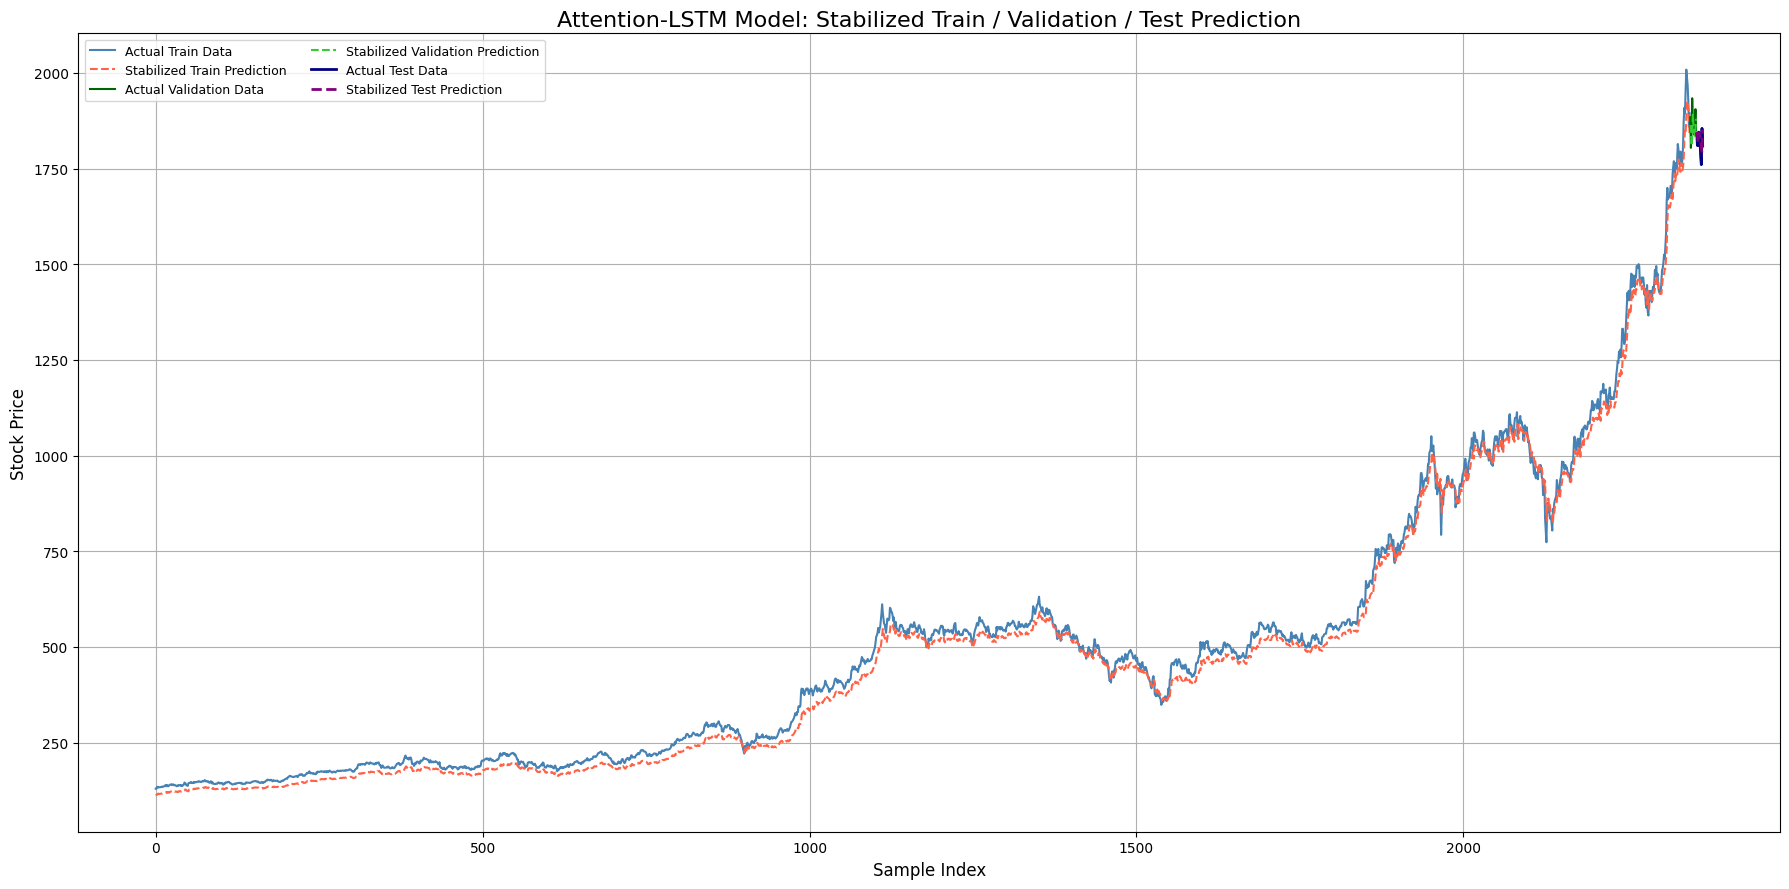

Visualization of Attention-LSTM predictions complete.


In [165]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 9))

train_idx = np.arange(len(y_train_inverse))
val_idx = np.arange(len(y_train_inverse), len(y_train_inverse) + len(y_val_inverse))
test_idx = np.arange(len(y_train_inverse) + len(y_val_inverse), len(y_train_inverse) + len(y_val_inverse) + len(y_test_inverse))

ax.plot(train_idx, y_train_inverse, label='Actual Train Data', color='steelblue', linewidth=1.5)
ax.plot(train_idx, train_predict_attention, label='Stabilized Train Prediction', color='tomato', linestyle='--', linewidth=1.5)
ax.plot(val_idx, y_val_inverse, label='Actual Validation Data', color='darkgreen', linewidth=1.5)
ax.plot(val_idx, val_predict_attention, label='Stabilized Validation Prediction', color='limegreen', linestyle='--', linewidth=1.5)
ax.plot(test_idx, y_test_inverse, label='Actual Test Data', color='navy', linewidth=2)
ax.plot(test_idx, test_predict_attention, label='Stabilized Test Prediction', color='purple', linestyle='--', linewidth=2)

ax.set_title('Attention-LSTM Model: Stabilized Train / Validation / Test Prediction', fontsize=16)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True)

plt.tight_layout()
plt.show()
print("Visualization of Attention-LSTM predictions complete.")

## Evaluate Attention-LSTM Model Performance

### Subtask:
Calculate and report evaluation metrics, such as Root Mean Squared Error (RMSE), for both the training and testing predictions to quantitatively assess the performance of the Attention-LSTM model. This will provide a clear measure of accuracy.


The Root Mean Squared Error (RMSE) is a commonly used metric to measure the difference between values predicted by a model and the values observed. In the context of stock price prediction, RMSE quantifies the average magnitude of the errors made by the model in predicting stock prices. A lower RMSE value indicates a better fit of the model to the data. It is particularly useful because it gives a relatively high weight to large errors, meaning it is sensitive to outliers. The RMSE values for both the training and testing sets will indicate how well the Attention-LSTM model learned from the historical data and how well it generalizes to unseen data, respectively.

**Reasoning**:
Now that the explanation for RMSE has been provided, I will print the already calculated `train_rmse` and `test_rmse` values to report the evaluation metrics as required by the subtask.



In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

def regression_summary(split_name, y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        'Split': split_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE(%)': mean_absolute_percentage_error(y_true, y_pred),
    }

metrics_df = pd.DataFrame(
    [
        regression_summary('Train', y_train_inverse, train_predict_attention),
        regression_summary('Validation', y_val_inverse, val_predict_attention),
        regression_summary('Test', y_test_inverse, test_predict_attention),
    ]
)
display(metrics_df)

train_rmse, train_mae, train_mape = metrics_df.loc[metrics_df['Split'] == 'Train', ['RMSE', 'MAE', 'MAPE(%)']].iloc[0]
val_rmse, val_mae, val_mape = metrics_df.loc[metrics_df['Split'] == 'Validation', ['RMSE', 'MAE', 'MAPE(%)']].iloc[0]
test_rmse, test_mae, test_mape = metrics_df.loc[metrics_df['Split'] == 'Test', ['RMSE', 'MAE', 'MAPE(%)']].iloc[0]

print("Stabilized Attention-LSTM Model Performance Metrics:")
print(f"Stabilization alpha: {stabilization_alpha:.2f}")
print(f"Train RMSE: {train_rmse:.4f}, Train MAPE: {train_mape:.2f}%")
print(f"Validation RMSE: {val_rmse:.4f}, Validation MAPE: {val_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.4f}, Test MAPE: {test_mape:.2f}%")

,Split,RMSE,MAE,MAPE(%)
0,Train,27.160568,23.574327,6.670310
1,Validation,44.454857,35.072109,1.867701
2,Test,33.941575,28.270148,1.560115


Stabilized Attention-LSTM Model Performance Metrics:
Stabilization alpha: 0.40
Train RMSE: 27.1606, Train MAPE: 6.67%
Validation RMSE: 44.4549, Validation MAPE: 1.87%
Test RMSE: 33.9416, Test MAPE: 1.56%


In [167]:
# === Phase 2: Rolling Forecast Simulation ===
# We use the final 10 valid trading days as the rolling forecast target window.
historical_data = scaled_close_prices[:-forecast_days]
actual_future_prices = scaled_close_prices[-forecast_days:]
actual_future_prices_inv = scaler.inverse_transform(actual_future_prices)
rolling_dates = test_dates

rolling_predictions = []
current_window = historical_data[-look_back:].reshape(1, look_back, 1)

print("Starting rolling forecast on the final test window...")
model_with_attention.load_state_dict(load_model_weights(best_model_path, device))
model_with_attention.eval()

for i in range(forecast_days):
    current_window_tensor = torch.tensor(current_window, dtype=torch.float32).to(device)
    with torch.no_grad():
        next_pred_raw = model_with_attention(current_window_tensor).cpu().numpy()[0][0]
    anchor_scaled = current_window[0, -1, 0]
    next_pred = stabilization_alpha * next_pred_raw + (1 - stabilization_alpha) * anchor_scaled
    rolling_predictions.append(next_pred)

    # Use the real observed close price for day t+1 to update the next prediction window.
    actual_next_day = actual_future_prices[i]
    new_element = np.array([[[actual_next_day[0]]]])
    current_window = np.append(current_window[:, 1:, :], new_element, axis=1)

rolling_predictions_inv = scaler.inverse_transform(np.array(rolling_predictions).reshape(-1, 1))
rolling_rmse = np.sqrt(mean_squared_error(actual_future_prices_inv.reshape(-1), rolling_predictions_inv.reshape(-1)))
rolling_mape = mean_absolute_percentage_error(actual_future_prices_inv, rolling_predictions_inv)

rolling_results_df = pd.DataFrame(
    {
        'Date': pd.to_datetime(rolling_dates),
        'Actual Close': actual_future_prices_inv.reshape(-1),
        'Rolling Predicted Close': rolling_predictions_inv.reshape(-1),
    }
)
display(rolling_results_df)
print(f"Stabilization alpha used in rolling forecast: {stabilization_alpha:.2f}")
print(f"Rolling Forecast RMSE: {rolling_rmse:.4f}")
print(f"Rolling Forecast MAPE: {rolling_mape:.2f}%")

Starting rolling forecast on the final test window...


,Date,Actual Close,Rolling Predicted Close
0,2026-03-20 00:00:00+08:00,1840.0,1861.694011
1,2026-03-23 00:00:00+08:00,1810.0,1855.599643
2,2026-03-24 00:00:00+08:00,1810.0,1836.510990
3,2026-03-25 00:00:00+08:00,1845.0,1835.237451
4,2026-03-26 00:00:00+08:00,1840.0,1856.333517
5,2026-03-27 00:00:00+08:00,1820.0,1855.016907
6,2026-03-30 00:00:00+08:00,1780.0,1844.603496
7,2026-03-31 00:00:00+08:00,1760.0,1821.347739
8,2026-04-01 00:00:00+08:00,1855.0,1809.169023
9,2026-04-02 00:00:00+08:00,1810.0,1865.771682


Stabilization alpha used in rolling forecast: 0.40
Rolling Forecast RMSE: 42.4137
Rolling Forecast MAPE: 2.12%


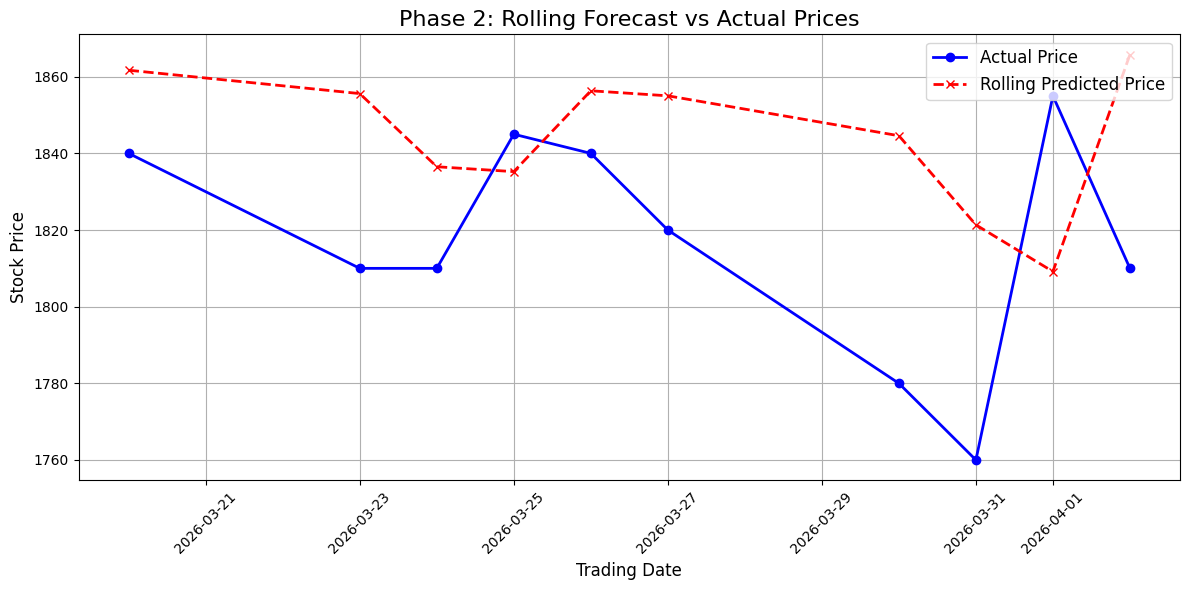

In [168]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rolling_results_df['Date'], rolling_results_df['Actual Close'], marker='o', label='Actual Price', color='blue', linewidth=2)
ax.plot(rolling_results_df['Date'], rolling_results_df['Rolling Predicted Close'], marker='x', label='Rolling Predicted Price', color='red', linestyle='--', linewidth=2)

ax.set_title('Phase 2: Rolling Forecast vs Actual Prices', fontsize=16)
ax.set_xlabel('Trading Date', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.show()

## Future 10-Day Forecast and Model Analysis Helper

- 這一格會用目前資料中最後一筆有效的 `Close` 作為起點，自動往後預測 10 個 future steps。
- 如果 CSV 中 `2026-04-02` 的 `Close` 已經補齊，這段程式就會自動從 `2026-04-02` 往後預測；如果 `Close` 還是空值，則會從目前最後一筆有效收盤價日期開始。
- 下方也整理了 `Stock_predict(1).ipynb` 的 sample baseline 設定，方便你做 `Model Analysis` 比較。

,Future Step,Approx. Business Date,Predicted Close
0,1,2026-04-03,1838.748190
1,2,2026-04-06,1857.593316
2,3,2026-04-07,1872.771562
3,4,2026-04-08,1886.161683
4,5,2026-04-09,1896.138699
5,6,2026-04-10,1902.442884
6,7,2026-04-13,1907.377337
7,8,2026-04-14,1912.391964
8,9,2026-04-15,1917.568877
9,10,2026-04-16,1921.436420


Latest valid Close used for future forecast: 2026-04-02
Stabilization alpha used in future forecast: 0.40
Approx. Business Date excludes weekends but does not remove Taiwan market holidays.


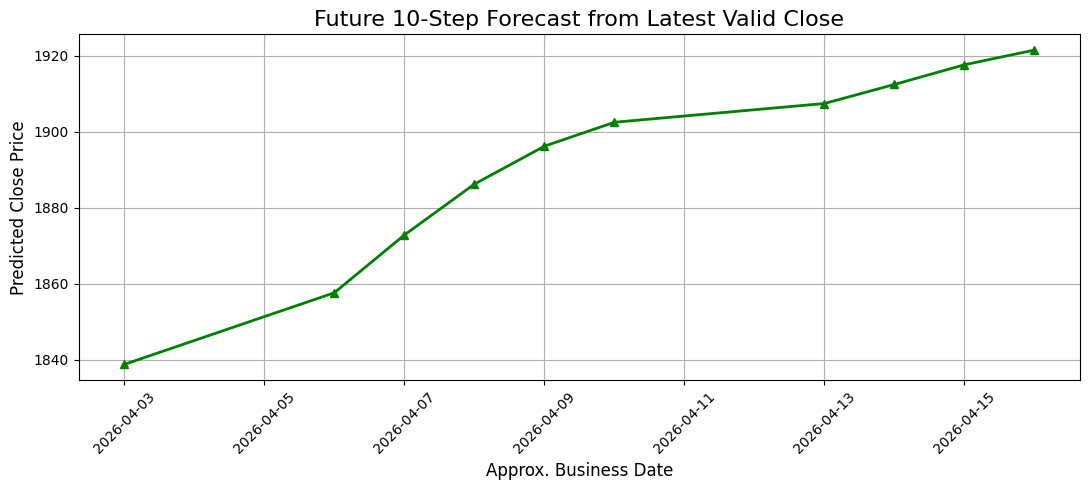

,Notebook,Framework,Feature,look_back,Split,Architecture,Dropout,Optimizer,Epochs,Batch Size
0,Stock_predict(1).ipynb sample baseline,TensorFlow / Keras,Close only,100,"train_test_split(test_size=0.05, shuffle=False)",LSTM(128) -> LSTM(64) -> Attention -> Dense(1),0.0,Adam,50,32
1,Stock_predict_torch_v1.ipynb current model,PyTorch,Close only,60,train / validation / test = all_except_last_20...,LSTM(64) -> LSTM(32) -> Attention -> Dense(1),0.1,Adam,650,64


,Experiment,look_back,hidden_size1,hidden_size2,dropout,stabilization_alpha,learning_rate,batch_size,epochs,validation_RMSE,validation_MAPE(%),test_RMSE,test_MAPE(%),rolling_RMSE,rolling_MAPE(%)
0,Attention-LSTM current best run,60,64,32,0.1,0.4,0.001,64,650,44.4549,1.87,33.9416,1.56,42.4137,2.12


,Model,RMSE,MAPE(%),Notes
0,Sample baseline from Stock_predict(1).ipynb,NaN,NaN,"For a fair comparison, rerun Stock_predict(1)...."
1,PyTorch Attention-LSTM best model,33.9416,1.56,"look_back=60, hidden=(64, 32), dropout=0.1, al..."


,Date,Predicted Price,Actual Close,Action,Transaction Amount,Cash Balance,Holdings,Total Asset


1. Future forecast: include the final 10-step prediction table and chart.
2. Model Analysis: compare the sample baseline vs your PyTorch best model with RMSE / MAPE.
3. Explain why look_back, hidden units, dropout, and train/validation/test split affected performance.
4. Mention that missing Close rows were removed before evaluation and forecasting.
5. Phase 2: include the rolling forecast plot, table, RMSE, and MAPE.
6. Phase 3 report PDF: fill the trading log and compute ROI / Max Drawdown.


In [169]:
# === Future 10-Day Forecast using the latest valid Close ===
future_days = 10
latest_valid_timestamp = pd.Timestamp(latest_valid_close_date)
if latest_valid_timestamp.tzinfo is not None:
    latest_valid_timestamp = latest_valid_timestamp.tz_localize(None)

future_window = scaled_close_prices[-look_back:].reshape(1, look_back, 1)
future_predictions = []

model_with_attention.load_state_dict(load_model_weights(best_model_path, device))
model_with_attention.eval()

for _ in range(future_days):
    future_window_tensor = torch.tensor(future_window, dtype=torch.float32).to(device)
    with torch.no_grad():
        next_pred_raw = model_with_attention(future_window_tensor).cpu().numpy()[0][0]
    future_anchor_scaled = future_window[0, -1, 0]
    next_pred = stabilization_alpha * next_pred_raw + (1 - stabilization_alpha) * future_anchor_scaled
    future_predictions.append(next_pred)
    new_element = np.array([[[next_pred]]])
    future_window = np.append(future_window[:, 1:, :], new_element, axis=1)

future_predictions_inv = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)).reshape(-1)
approx_future_dates = pd.bdate_range(start=latest_valid_timestamp + pd.offsets.BDay(1), periods=future_days)

future_forecast_df = pd.DataFrame(
    {
        'Future Step': np.arange(1, future_days + 1),
        'Approx. Business Date': approx_future_dates,
        'Predicted Close': future_predictions_inv,
    }
)
display(future_forecast_df)

print(f"Latest valid Close used for future forecast: {latest_valid_timestamp.date()}")
print(f"Stabilization alpha used in future forecast: {stabilization_alpha:.2f}")
if removed_rows > 0:
    print(
        f"Note: raw file contained {removed_rows} row(s) with missing Close. Forecast starts from the latest valid Close above."
    )
print("Approx. Business Date excludes weekends but does not remove Taiwan market holidays.")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(future_forecast_df['Approx. Business Date'], future_forecast_df['Predicted Close'], marker='^', color='green', linewidth=2)
ax.set_title('Future 10-Step Forecast from Latest Valid Close', fontsize=16)
ax.set_xlabel('Approx. Business Date', fontsize=12)
ax.set_ylabel('Predicted Close Price', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
plt.tight_layout()
plt.show()

# === Sample code baseline summary from Stock_predict(1).ipynb ===
sample_baseline_rmse = None
sample_baseline_mape = None
sample_baseline_notes = 'For a fair comparison, rerun Stock_predict(1).ipynb on the same cleaned dataset, then fill in RMSE and MAPE here.'

sample_vs_torch_config_df = pd.DataFrame(
    [
        {
            'Notebook': 'Stock_predict(1).ipynb sample baseline',
            'Framework': 'TensorFlow / Keras',
            'Feature': 'Close only',
            'look_back': 100,
            'Split': 'train_test_split(test_size=0.05, shuffle=False)',
            'Architecture': 'LSTM(128) -> LSTM(64) -> Attention -> Dense(1)',
            'Dropout': 0.0,
            'Optimizer': 'Adam',
            'Epochs': 50,
            'Batch Size': 32,
        },
        {
            'Notebook': 'Stock_predict_torch_v1.ipynb current model',
            'Framework': 'PyTorch',
            'Feature': 'Close only',
            'look_back': look_back,
            'Split': 'train / validation / test = all_except_last_20 / 10 / 10',
            'Architecture': f'LSTM({hidden_size1}) -> LSTM({hidden_size2}) -> Attention -> Dense(1)',
            'Dropout': dropout_rate,
            'Optimizer': 'Adam',
            'Epochs': epochs,
            'Batch Size': batch_size,
        },
    ]
)
display(sample_vs_torch_config_df)

experiment_log_df = pd.DataFrame(
    [
        {
            'Experiment': 'Attention-LSTM current best run',
            'look_back': look_back,
            'hidden_size1': hidden_size1,
            'hidden_size2': hidden_size2,
            'dropout': dropout_rate,
            'stabilization_alpha': round(stabilization_alpha, 2),
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
            'validation_RMSE': round(val_rmse, 4),
            'validation_MAPE(%)': round(val_mape, 2),
            'test_RMSE': round(test_rmse, 4),
            'test_MAPE(%)': round(test_mape, 2),
            'rolling_RMSE': round(rolling_rmse, 4),
            'rolling_MAPE(%)': round(rolling_mape, 2),
        }
    ]
)
display(experiment_log_df)

model_analysis_df = pd.DataFrame(
    [
        {
            'Model': 'Sample baseline from Stock_predict(1).ipynb',
            'RMSE': sample_baseline_rmse,
            'MAPE(%)': sample_baseline_mape,
            'Notes': sample_baseline_notes,
        },
        {
            'Model': 'PyTorch Attention-LSTM best model',
            'RMSE': round(test_rmse, 4),
            'MAPE(%)': round(test_mape, 2),
            'Notes': f'look_back={look_back}, hidden=({hidden_size1}, {hidden_size2}), dropout={dropout_rate}, alpha={stabilization_alpha:.2f}, lr={learning_rate}, batch_size={batch_size}, epochs={epochs}',
        },
    ]
)
display(model_analysis_df)

trading_log_template = pd.DataFrame(
    columns=['Date', 'Predicted Price', 'Actual Close', 'Action', 'Transaction Amount', 'Cash Balance', 'Holdings', 'Total Asset']
)
display(trading_log_template)

reflection_checklist = [
    '1. Future forecast: include the final 10-step prediction table and chart.',
    '2. Model Analysis: compare the sample baseline vs your PyTorch best model with RMSE / MAPE.',
    '3. Explain why look_back, hidden units, dropout, and train/validation/test split affected performance.',
    '4. Mention that missing Close rows were removed before evaluation and forecasting.',
    '5. Phase 2: include the rolling forecast plot, table, RMSE, and MAPE.',
    '6. Phase 3 report PDF: fill the trading log and compute ROI / Max Drawdown.',
]
for item in reflection_checklist:
    print(item)